In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Membaca data CSV
data = pd.read_csv('//content/data_iklim.csv.csv')
# Melihat 5 data pertama
print(data.head())

  precipitation max temperature min temperature         wind  \
0   22,17864727          22,579          16,226   0,98477418   
1   10,77861942          29,369         20,2985  1,054619598   
2   9,443091888          27,384           18,62  0,999835774   
3   15,51303961         21,7585         14,9085  0,922273123   
4   15,21262902          24,568          17,651  1,078517568   

  relative humidity        solar  
0       0,949216707  12,98674041  
1       0,837694214  20,63957504  
2       0,869631027  18,48553254  
3        0,95195662  9,497525996  
4       0,927156092  15,35485704  


In [ ]:
data.rename(columns={'precipitation (Y)': 'Y', 'max temperature (X1)': 'X1', 'min temperature (X2)': 'X2','wind (X3)': 'X3','relative humidity (X4)': 'X4' }, inplace=True)
print(data)

            Y       X1       X2        X3        X4      solar
0   22.178647  22.5790  16.2260  0.984774  0.949217  12.986740
1   10.778619  29.3690  20.2985  1.054620  0.837694  20.639575
2    9.443092  27.3840  18.6200  0.999836  0.869631  18.485533
3   15.513040  21.7585  14.9085  0.922273  0.951957   9.497526
4   15.212629  24.5680  17.6510  1.078518  0.927156  15.354857
..        ...      ...      ...       ...       ...        ...
73  12.599952  28.5500  27.6160  4.894644  0.778710  24.586383
74  15.132806  28.3940  27.4405  5.250058  0.782321  24.467849
75  10.986334  28.2970  27.3200  5.626393  0.784487  23.705266
76   9.758090  28.4465  27.4975  5.078008  0.777539  23.123691
77   8.621691  28.6175  27.6740  4.858509  0.769383  22.735279

[78 rows x 6 columns]


In [ ]:
# Menghitung matriks korelasi
correlation_matrix = data.corr()
print(correlation_matrix)

              Y        X1        X2        X3        X4     solar
Y      1.000000 -0.752439 -0.602791 -0.338976  0.640560 -0.636573
X1    -0.752439  1.000000  0.797165  0.449202 -0.736253  0.909192
X2    -0.602791  0.797165  1.000000  0.835801 -0.952236  0.878219
X3    -0.338976  0.449202  0.835801  1.000000 -0.760450  0.665849
X4     0.640560 -0.736253 -0.952236 -0.760450  1.000000 -0.778746
solar -0.636573  0.909192  0.878219  0.665849 -0.778746  1.000000


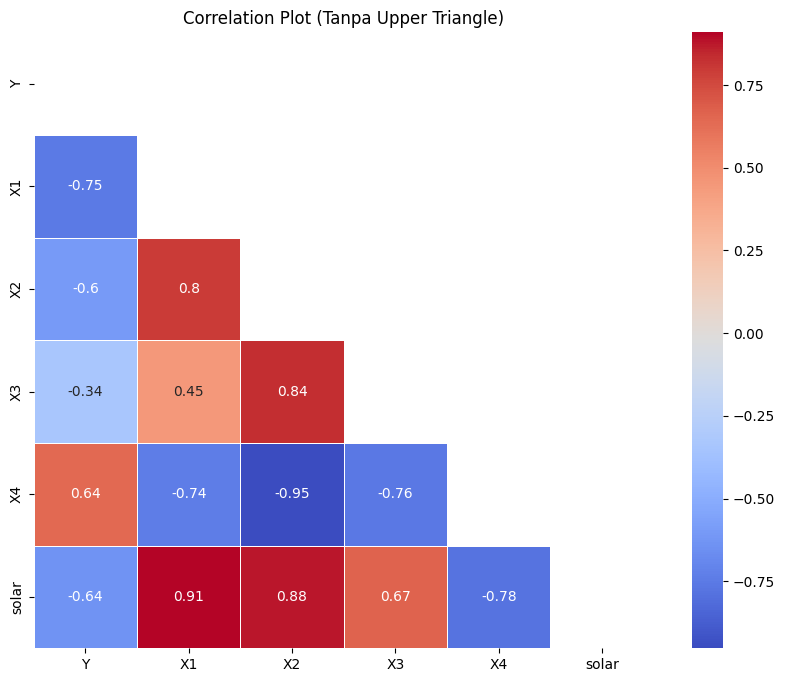

In [ ]:
# Membuat mask untuk upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Membuat heatmap tanpa upper triangle
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Plot (Tanpa Upper Triangle)')
plt.show()


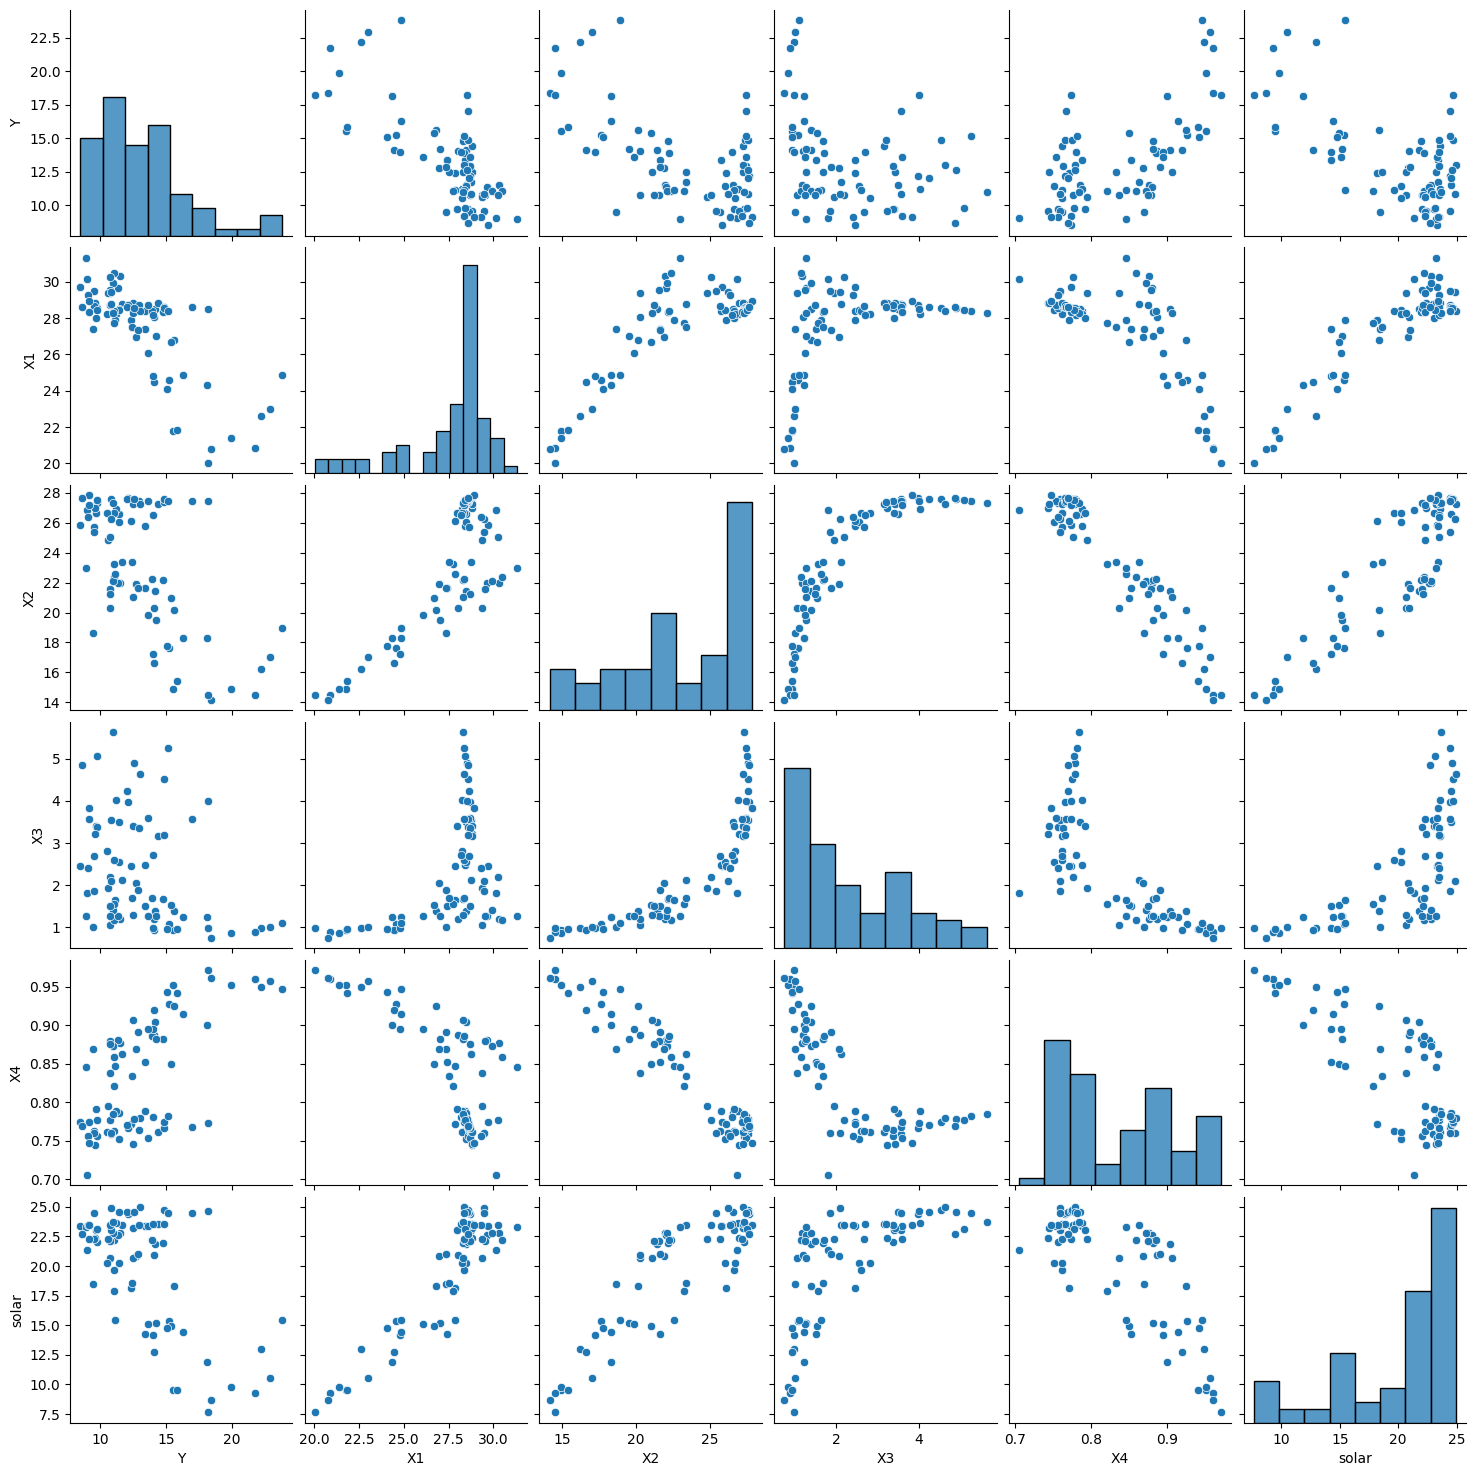

In [ ]:
sns.pairplot(data)
plt.show()


In [ ]:
data.describe()

,Y,X1,X2,X3,X4,solar
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,13.132865,27.490365,23.146955,2.305010,0.834104,19.934961
std,3.418236,2.500029,4.200603,1.292227,0.072323,4.813028
min,8.486084,20.026000,14.145000,0.747965,0.705405,7.636051
25%,10.784413,27.119375,20.296625,1.236886,0.769628,16.057093
50%,12.487076,28.384500,23.363250,1.871477,0.827701,22.161093
75%,14.823173,28.745500,27.144000,3.371683,0.890721,23.443735
max,23.816297,31.337000,27.852000,5.626393,0.972020,24.954589


In [ ]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = data[['X1','X2','X3','X4']]  # Variabel independen
Y = data['Y']  # Variabel dependen

In [ ]:
print(X)

         X1       X2        X3        X4
0   22.5790  16.2260  0.984774  0.949217
1   29.3690  20.2985  1.054620  0.837694
2   27.3840  18.6200  0.999836  0.869631
3   21.7585  14.9085  0.922273  0.951957
4   24.5680  17.6510  1.078518  0.927156
..      ...      ...       ...       ...
73  28.5500  27.6160  4.894644  0.778710
74  28.3940  27.4405  5.250058  0.782321
75  28.2970  27.3200  5.626393  0.784487
76  28.4465  27.4975  5.078008  0.777539
77  28.6175  27.6740  4.858509  0.769383

[78 rows x 4 columns]


In [ ]:
print(Y)

0     22.178647
1     10.778619
2      9.443092
3     15.513040
4     15.212629
        ...    
73    12.599952
74    15.132806
75    10.986334
76     9.758090
77     8.621691
Name: Y, Length: 78, dtype: float64


In [ ]:
# Menambahkan konstanta ke model (intercept)
X = sm.add_constant(X)

print(X)

    const       X1       X2        X3        X4
0     1.0  22.5790  16.2260  0.984774  0.949217
1     1.0  29.3690  20.2985  1.054620  0.837694
2     1.0  27.3840  18.6200  0.999836  0.869631
3     1.0  21.7585  14.9085  0.922273  0.951957
4     1.0  24.5680  17.6510  1.078518  0.927156
..    ...      ...      ...       ...       ...
73    1.0  28.5500  27.6160  4.894644  0.778710
74    1.0  28.3940  27.4405  5.250058  0.782321
75    1.0  28.2970  27.3200  5.626393  0.784487
76    1.0  28.4465  27.4975  5.078008  0.777539
77    1.0  28.6175  27.6740  4.858509  0.769383

[78 rows x 5 columns]


In [ ]:
#ubah X dan Y menjadi bentuk matriks
X_new = np.array(X)
y_new = np.array(Y)


In [ ]:
# transpose matriks X
XT = X_new.T

# menghitung (X'X)
XTX = np.dot(XT, X_new)
print(XTX)


In [ ]:
# transpose matriks X
XT = X_new.T

# menghitung (X'X)
XTX = np.dot(XT, X_new)

# menghitung invers (X'X)^(-1)
XTX_inv = np.linalg.inv(XTX)
print(XTX_inv)

[[ 4.50266886e+01  1.34633719e-01 -8.22881354e-01  5.25173708e-01
  -3.70197456e+01]
 [ 1.34633719e-01  1.14186207e-02 -1.33823745e-02  1.73174355e-02
  -2.14231477e-01]
 [-8.22881354e-01 -1.33823745e-02  2.72428673e-02 -3.02455607e-02
   7.55174818e-01]
 [ 5.25173708e-01  1.73174355e-02 -3.02455607e-02  5.32705395e-02
  -5.08249132e-01]
 [-3.70197456e+01 -2.14231477e-01  7.55174818e-01 -5.08249132e-01
   3.18911760e+01]]


In [ ]:
# menghitung X'Y
XTY =np.dot(XT,y_new)
print(XTY)

[ 1024.3635086  27665.00852832 23044.44051605  2245.87544903
   866.61962431]


In [ ]:

# menghitung beta
beta = np.dot(XTX_inv,XTY)

print("Koefisien beta:")
print(beta)

Koefisien beta:
[-17.06396624  -1.3436257    1.1650537   -0.75591458  50.24375866]


In [ ]:
# Membuat model regresi linear
model = sm.OLS(Y, X).fit()

# Melihat ringkasan model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.635
Method:                 Least Squares   F-statistic:                     34.53
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           3.65e-16
Time:                        05:19:28   Log-Likelihood:                -164.63
No. Observations:                  78   AIC:                             339.3
Df Residuals:                      73   BIC:                             351.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.0640     13.852     -1.232      0.2

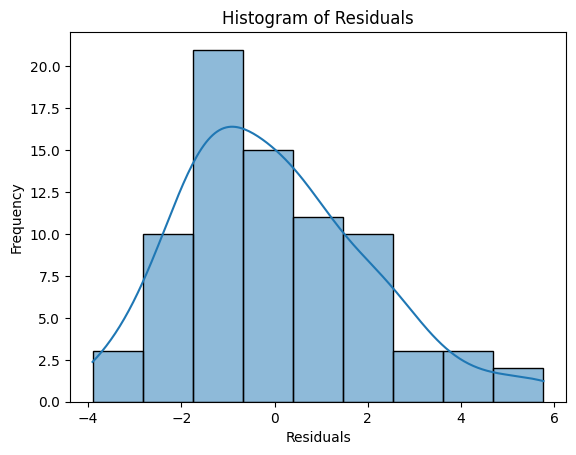

Shapiro-Wilk Test: W=0.9675664721585687, p-value=0.04403645177684296


In [ ]:
# Plot Histogram Residual
residuals = model.resid
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Uji Normalitas menggunakan Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
print(f'Shapiro-Wilk Test: W={shapiro_test[0]}, p-value={shapiro_test[1]}')


In [ ]:
#transformasi ln
# Membuat model regresi linear
model_ln = sm.OLS(np.log(Y), X).fit()

# Melihat ringkasan model
print(model_ln.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     32.74
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.26e-15
Time:                        05:20:03   Log-Likelihood:                 40.675
No. Observations:                  78   AIC:                            -71.35
Df Residuals:                      73   BIC:                            -59.57
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1190      0.996      0.119      0.9

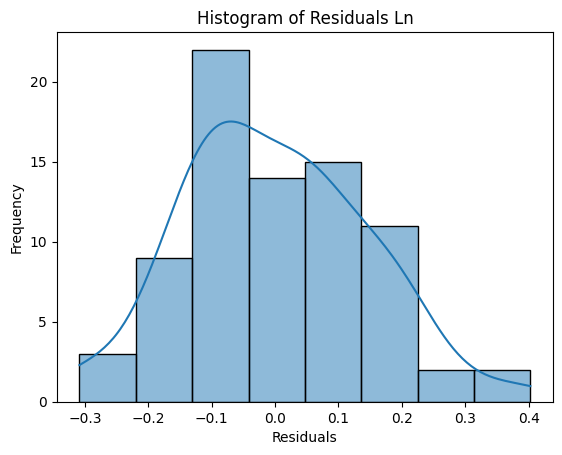

Shapiro-Wilk Test: W=0.9675664721585687, p-value=0.5522653380612332


In [ ]:
# Plot Histogram Residual
residuals_ln = model_ln.resid
sns.histplot(residuals_ln, kde=True)
plt.title('Histogram of Residuals Ln')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# Uji Normalitas menggunakan Shapiro-Wilk
shapiro_test_ln = stats.shapiro(residuals_ln)
print(f'Shapiro-Wilk Test: W={shapiro_test[0]}, p-value={shapiro_test_ln[1]}')


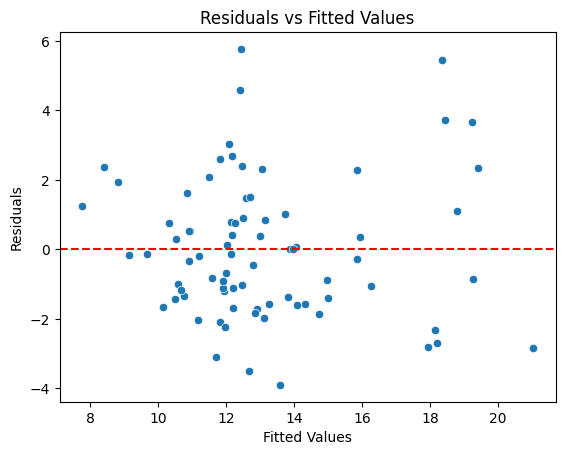

Breusch-Pagan Test: p-value=0.01311528789025524


In [ ]:
# Plot Residual vs Fitted Values
fitted_values = model.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Uji Homoskedastisitas menggunakan Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, X)
print(f'Breusch-Pagan Test: p-value={bp_test[1]}')


In [ ]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson

# Melakukan Uji Breusch-Godfrey untuk Autokorelasi
dw_test = durbin_watson(residuals)
bg_test = acorr_breusch_godfrey(model, nlags=1)
p_value = bg_test[1]  # Mendapatkan p-value



print(f'Breusch-Pagan Value: {dw_test}')
print(f'Breusch-Godfrey p-value: {p_value}')

Breusch-Pagan Value: 1.765882135379263
Breusch-Godfrey p-value: 0.47162353339137264


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF (Variance Inflation Factor)
VIF = pd.DataFrame()
VIF["variables"] = X.columns
VIF["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(VIF)


  variables           VIF
0     const  13532.257379
1        X1    562.152959
2        X2      1.857017
3        X3     11.602143
4        X4    555.232866
